In [ ]:
import pandas as pd
import numpy as np
import random
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

In [9]:
data_2022= pd.read_csv('../data/processed_22.csv')
data_2023 = pd.read_csv('../data/processed_23.csv')

data_2024 = pd.read_csv('../data/processed_24.csv')
data_2025 = pd.read_csv('../data/processed_25.csv')
total = pd.concat([data_2022, data_2023, data_2024, data_2025], ignore_index=True)  

In [10]:
total = total.sort_values('date').reset_index(drop=True)
total['date'] = pd.to_datetime(total['date'])
total = total.set_index('date')

split_index = int(len(total) * 0.75)
train = total.iloc[:split_index]
test = total.iloc[split_index:]


In [11]:
y_train = train['Lpoly_expected_ml']
y_test = test['Lpoly_expected_ml']


In [12]:
bare_baseline = y_train.iloc[-1]
baseline_preds = np.repeat(bare_baseline, len(y_test))

In [35]:
model = ARIMA(y_train, order=(5,1,0))
model_fit = model.fit()
forecast_detail = model_fit.get_forecast(steps=len(y_test)) 
conf_int = forecast_detail.conf_int()
forecast = forecast_detail.predicted_mean

In [36]:
#to line up dates 
forecast.index = y_test.index
conf_int.index = y_test.index

In [37]:
print(y_test.shape)
print(forecast.shape)
print(conf_int.shape)

(202,)
(202,)
(202, 2)


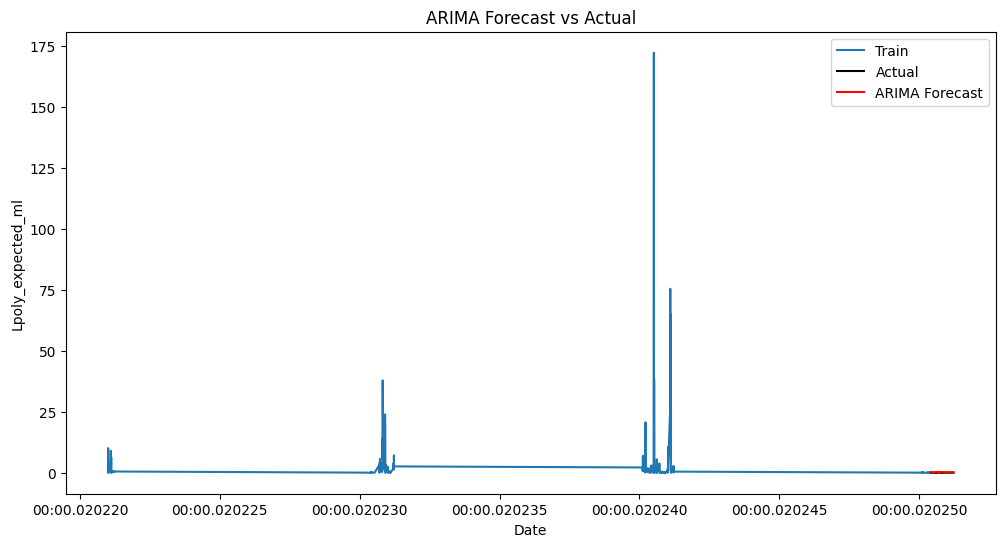

In [38]:
plt.figure(figsize=(12,6))

plt.plot(y_train.index, y_train, label='Train')
plt.plot(y_test.index, y_test, label='Actual', color='black')
plt.plot(y_test.index, forecast, label='ARIMA Forecast', color='red')

plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Lpoly_expected_ml')
plt.legend()
plt.show()

In [39]:
rmse = np.sqrt(mean_squared_error(y_test, forecast))
mae = mean_absolute_error(y_test, forecast)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.18893003030770886
MAE: 0.18788427636100585


In [40]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(y_train)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.165063164298931
p-value: 1.0356947479198967e-05


In [48]:
#rolling forecast 
history = [x for x in y_train]
predictions = list()
# walk-forward validation
for t in range(len(y_test)):
	model = ARIMA(history, order=(5,1,0))
	model_fit = model.fit()
	output = model_fit.forecast()
	yhat = output[0]
	predictions.append(yhat)
	obs = y_test.iloc[t]
	history.append(obs)
	print('predicted=%f, expected=%f' % (yhat, obs))

predicted=0.273831, expected=0.000928
predicted=-0.033343, expected=0.000402
predicted=-0.006488, expected=0.002657
predicted=0.068682, expected=0.001794
predicted=0.020783, expected=0.008106
predicted=0.012204, expected=0.009292
predicted=0.008204, expected=0.005529
predicted=0.004024, expected=0.001746
predicted=0.001962, expected=0.003466
predicted=0.004750, expected=0.001238
predicted=0.002406, expected=0.002505
predicted=0.002643, expected=0.000923
predicted=0.001382, expected=0.002620
predicted=0.002528, expected=0.030539
predicted=0.028092, expected=0.016873
predicted=0.013085, expected=0.002762
predicted=-0.001168, expected=0.005123
predicted=0.008846, expected=0.022086
predicted=0.024421, expected=0.006149
predicted=0.005373, expected=0.005463
predicted=0.003758, expected=0.015202
predicted=0.017394, expected=0.006713
predicted=0.006906, expected=0.020840
predicted=0.018712, expected=0.028569
predicted=0.027064, expected=0.022086
predicted=0.018090, expected=0.006359
predicted

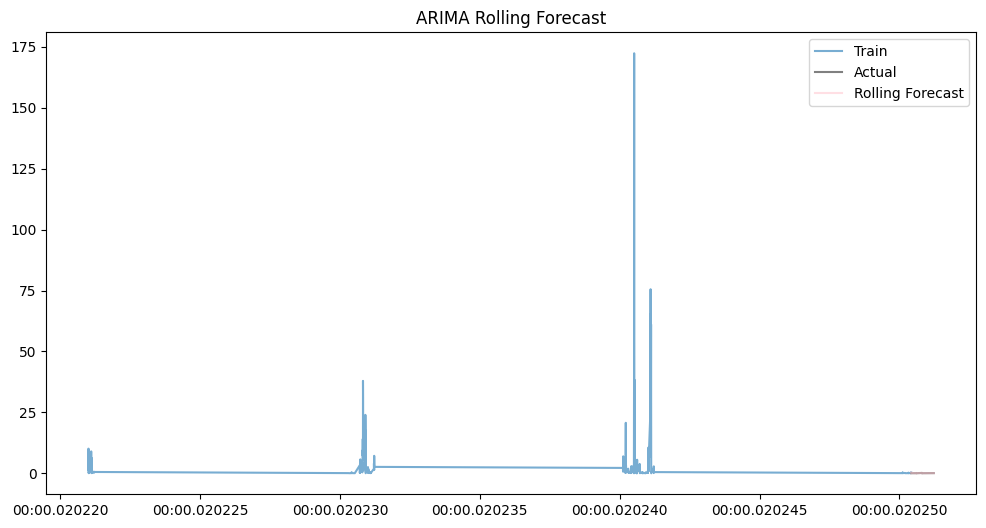

In [76]:
import matplotlib.pyplot as plt

# Convert predictions to Series aligned with test index
pred_series = pd.Series(predictions, index=y_test.index)

plt.figure(figsize=(12,6))

plt.plot(y_train.index, y_train, label='Train', alpha=0.6)
plt.plot(y_test.index, y_test, label='Actual', color='grey')
plt.plot(pred_series.index, pred_series, label='Rolling Forecast', color='pink',alpha=0.5)

plt.title('ARIMA Rolling Forecast')
plt.legend()
plt.show()

In [51]:
history = []
rolling_preds = []

for t in range(len(total)):
    if t < 5:
        rolling_preds.append(np.nan)
        history.append(total['Lpoly_expected_ml'].iloc[t])
        continue
        
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    
    rolling_preds.append(yhat)
    history.append(total['Lpoly_expected_ml'].iloc[t])

rolling_series = pd.Series(rolling_preds, index=total.index)

In [56]:
rolling_series.index

DatetimeIndex(['1970-01-01 00:00:00.020221005',
               '1970-01-01 00:00:00.020221006',
               '1970-01-01 00:00:00.020221007',
               '1970-01-01 00:00:00.020221008',
               '1970-01-01 00:00:00.020221009',
               '1970-01-01 00:00:00.020221010',
               '1970-01-01 00:00:00.020221011',
               '1970-01-01 00:00:00.020221013',
               '1970-01-01 00:00:00.020221014',
               '1970-01-01 00:00:00.020221019',
               ...
               '1970-01-01 00:00:00.020251222',
               '1970-01-01 00:00:00.020251223',
               '1970-01-01 00:00:00.020251224',
               '1970-01-01 00:00:00.020251225',
               '1970-01-01 00:00:00.020251226',
               '1970-01-01 00:00:00.020251227',
               '1970-01-01 00:00:00.020251228',
               '1970-01-01 00:00:00.020251229',
               '1970-01-01 00:00:00.020251230',
               '1970-01-01 00:00:00.020251231'],
              dtype=

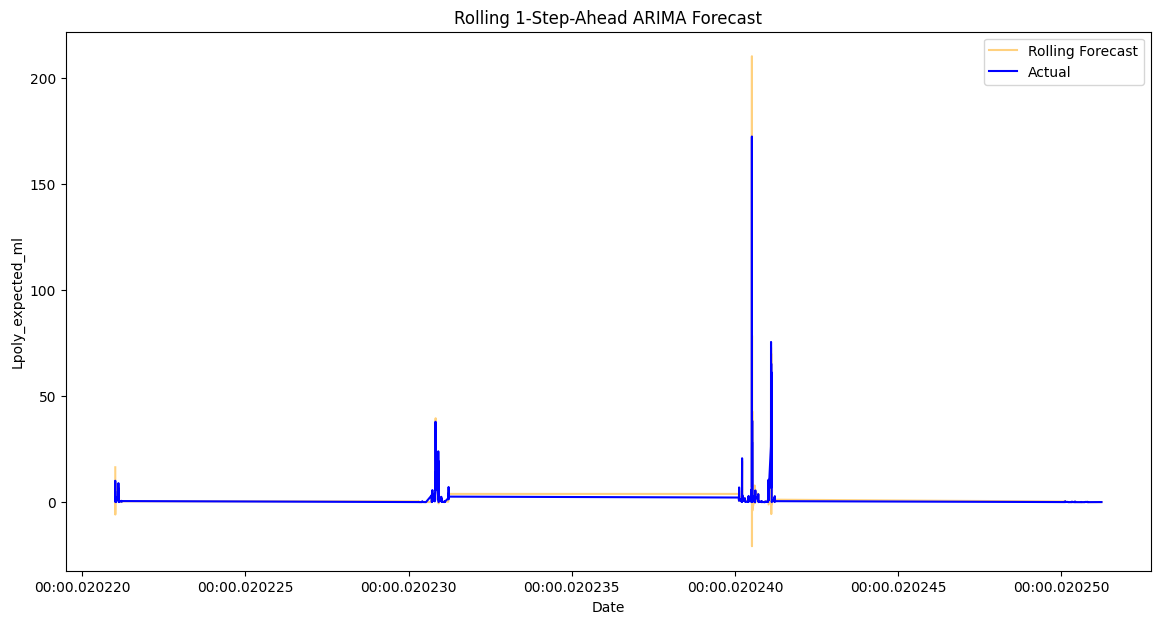

In [66]:
plt.figure(figsize=(14,7))

plt.plot(rolling_series.index[1:], rolling_series[1:], label='Rolling Forecast', color='orange',alpha=0.5)
plt.plot(total.index, total['Lpoly_expected_ml'], label='Actual', color='blue')
plt.title('Rolling 1-Step-Ahead ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Lpoly_expected_ml')
plt.legend()
plt.show()

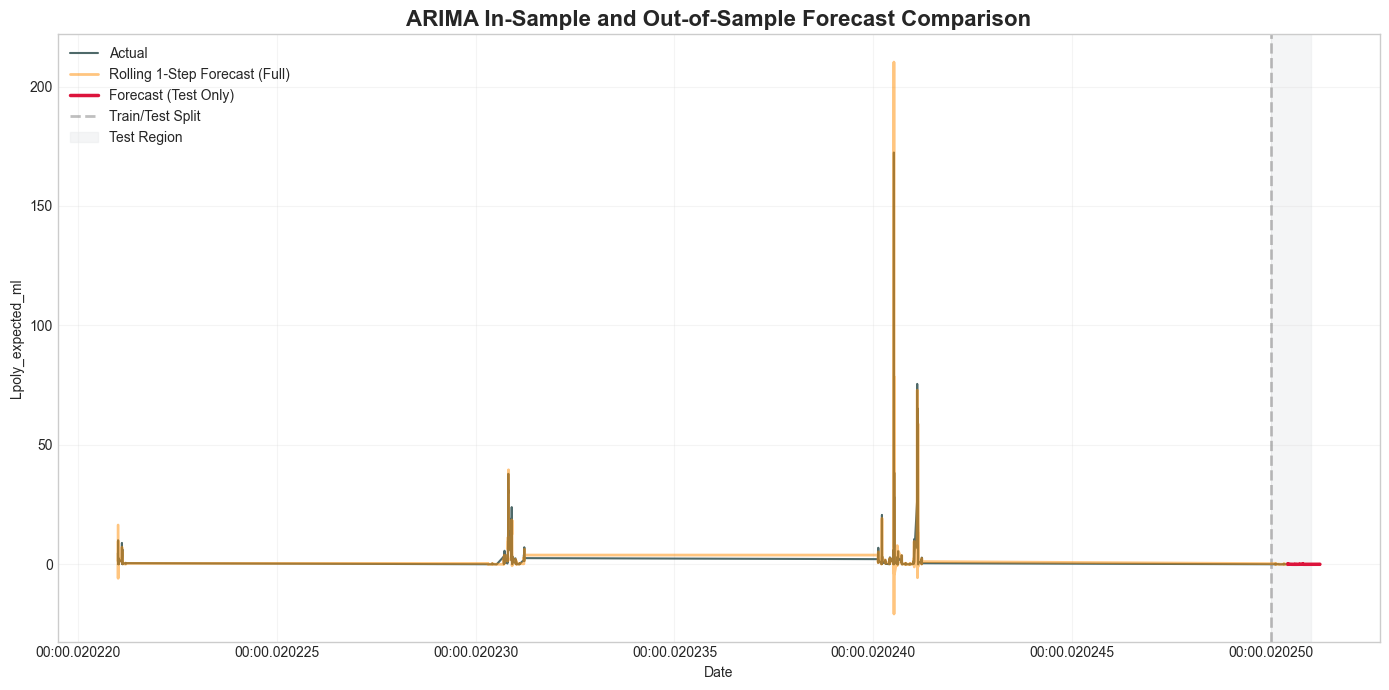

In [100]:
import matplotlib.pyplot as plt

# Align split date
split_date = total.index[split_index]

plt.figure(figsize=(14,7))
plt.style.use('seaborn-v0_8-whitegrid')
# 1️⃣ Full actual timeline (faded background)
plt.plot(total.index,
         total['Lpoly_expected_ml'],
         label='Actual',
        color='#2F4F4F',
         linestyle='-',
         alpha=0.85,
         linewidth=1.5,
         zorder=2)

# 2️⃣ Rolling forecast across full dataset
plt.plot(rolling_series.index,
         rolling_series,
         label='Rolling 1-Step Forecast (Full)',
         color='#FF8C00', # Dark Orange instead of yellow for contrast
         linestyle='-',
         linewidth=2,
         alpha=0.5,
         zorder=3)

# 3️⃣ Test-only forecast (from earlier method)
plt.plot(pred_series.index,
         pred_series,
         label='Forecast (Test Only)',
          color='#DC143C',
         linewidth=2.5,
         zorder=4)

# 4️⃣ Train/Test split line
plt.axvline(x=split_date,
            color='gray',
            linestyle='--',
            linewidth=2,
            alpha=0.5,
            label='Train/Test Split',
            zorder=2)

plt.axvspan(split_date, total.index[-1], 
           color='#EAECEE', 
           alpha=0.5, 
           label='Test Region',
           zorder=0)

plt.title('ARIMA In-Sample and Out-of-Sample Forecast Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Lpoly_expected_ml')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()